In [9]:
import scanpy as sc
import scvi
import numpy as np
import sys
sys.path.append('../')

from scripts.subset_hvg import subset_to_hvg

adata = sc.read_h5ad(
    "../../data/obesity_subset_CEBPB_KIF11.h5ad"
)

print(adata)

adata_hvg, hvg_genes = subset_to_hvg(
    adata,
    hvg_path="../../data/preprocessed/HVG/hvg5000_genes.txt"
)

print(adata_hvg)

AnnData object with n_obs × n_vars = 24325 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    uns: 'log1p'
    layers: 'counts'
HVG requested: 5000
HVG found in dataset: 5000
Missing genes: 0
AnnData object with n_obs × n_vars = 24325 × 5000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    uns: 'log1p'
    layers: 'counts'


In [49]:
adata_hvg.obs['gene'].value_counts()

gene
CEBPB          10782
NC              8660
KIF11           4705
CEBPB+NC          82
CEBPB+KIF11       42
NC+NC             28
KIF11+NC          26
Name: count, dtype: int64

In [57]:
from scripts.scoring import load_control_cells, reconstruct_full_expression_with_control, pearson_delta, mmd_metric
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
def evaluate_unseen_combination(

    adata_full,
    adata_hvg,

    dims=[256],

    target_pert="CEBPB+KIF11",

    perturbation_key="gene",
    batch_key="SampleID",

    control_source="NC+NC",

    seed=42   # <---- NEW
):

    ##################################
    # set seed
    ##################################

    np.random.seed(seed)


    ##################################
    # matrices
    ##################################

    X_hvg = adata_hvg.X

    if not isinstance(X_hvg,np.ndarray):
        X_hvg = X_hvg.toarray()

    X_full = adata_full.X

    if not isinstance(X_full,np.ndarray):
        X_full = X_full.toarray()


    ##################################
    # load control cells
    ##################################

    X_ctrl_pool = load_control_cells(

        control_source,
        adata_full.var_names
    )


    ##################################
    # control centroid
    ##################################

    control_centroid = X_ctrl_pool.mean(axis=0)


    ##################################
    # mask target perturbation
    ##################################

    target_mask = (
        adata_full.obs[
            perturbation_key
        ] == target_pert
    )


    results = []


    ##################################
    # PCA
    ##################################

    for d in dims:

        print("\nDIM =",d)


        ##################################
        # PCA with deterministic seed
        ##################################

        pca = PCA(
            n_components=d,
            random_state=seed
        )

        X_latent = pca.fit_transform(X_hvg)

        X_hvg_rec = pca.inverse_transform(
            X_latent
        )


        ##################################
        # sample target cells
        ##################################

        idx = sample_100_across_batches(

            adata_full,

            target_mask,

            batch_key=batch_key,

            n_cells=100
        )


        ##################################
        # sample control cells
        ##################################

        n_target = len(idx)

        ctrl_idx = np.random.choice(

            len(X_ctrl_pool),

            size=n_target,

            replace=True
        )

        X_ctrl_sample = X_ctrl_pool[ctrl_idx]


        ##################################
        # predicted expression
        ##################################

        X_pred = reconstruct_full_expression_with_control(

            adata_full,
            adata_hvg,

            X_hvg_rec[idx],

            X_ctrl_sample
        )


        ##################################
        # ground truth
        ##################################

        X_gt = X_full[idx]


        ##################################
        # delta
        ##################################

        delta_gt = (
            X_gt - control_centroid
        )

        delta_pred = (
            X_pred - control_centroid
        )


        ##################################
        # metrics
        ##################################

        pearson_score = pearson_delta(

            delta_gt,
            delta_pred
        )

        mmd_score = mmd_metric(

            delta_gt,
            delta_pred
        )


        ##################################
        # HVG reconstruction error
        ##################################

        rmse = np.sqrt(

            mean_squared_error(

                X_hvg[idx].flatten(),
                X_hvg_rec[idx].flatten()

            )
        )


        results.append({

            "dim":d,

            "control":control_source,

            "seed":seed,

            "pearson_delta":

                pearson_score,

            "mmd":

                mmd_score,

            "rmse_hvg":

                rmse

        })


        print(results[-1])


    return results

In [58]:
results = evaluate_unseen_combination(

    adata,
    adata_hvg,

    dims=[64,128,256,512],

    batch_key="SampleID",
    control_source="NC+NC"
)

NC+NC control loaded: (100, 36601)

DIM = 64
{'dim': 64, 'control': 'NC+NC', 'seed': 42, 'pearson_delta': np.float64(0.2704810644042203), 'mmd': np.float64(0.05188392582323542), 'rmse_hvg': np.float64(0.8554377702599325)}

DIM = 128
{'dim': 128, 'control': 'NC+NC', 'seed': 42, 'pearson_delta': np.float64(0.2873189273588182), 'mmd': np.float64(0.05079409996541954), 'rmse_hvg': np.float64(0.8401496430129608)}

DIM = 256
{'dim': 256, 'control': 'NC+NC', 'seed': 42, 'pearson_delta': np.float64(0.2651648785566856), 'mmd': np.float64(0.051070315286696276), 'rmse_hvg': np.float64(0.8110643806335096)}

DIM = 512
{'dim': 512, 'control': 'NC+NC', 'seed': 42, 'pearson_delta': np.float64(0.3362249522877223), 'mmd': np.float64(0.04913322901521731), 'rmse_hvg': np.float64(0.7533460705785007)}


In [59]:
############################################
# mapping between full genes and HVG genes
############################################

full_gene_list = adata.var_names.to_numpy()

hvg_mask = np.isin(
    full_gene_list,
    hvg_genes
)

non_hvg_mask = ~hvg_mask

print("total genes:", len(full_gene_list))
print("HVG genes:", np.sum(hvg_mask))

total genes: 36601
HVG genes: 10000


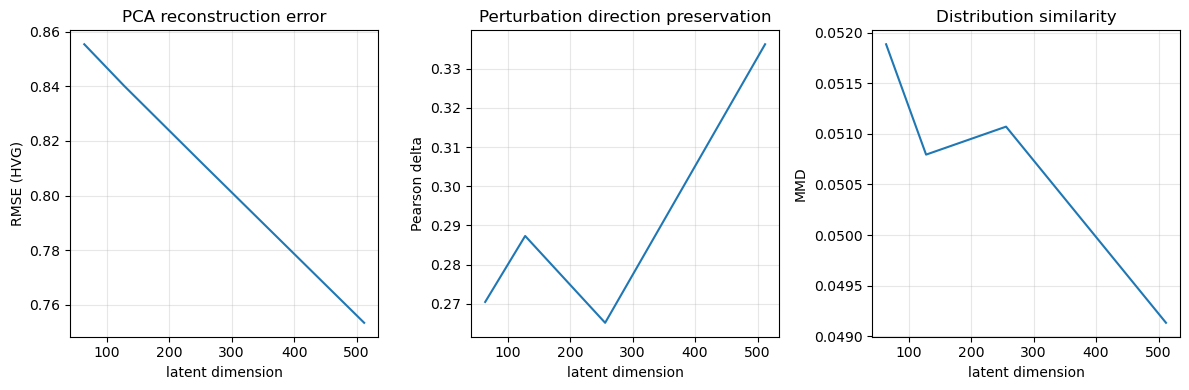


Suggested dimension:
best Pearson delta → 512
best MMD → 512


In [60]:
import matplotlib.pyplot as plt

dims = [r["dim"] for r in results]

rmse = [r["rmse_hvg"] for r in results]

pearson = [
    r["pearson_delta"]
    for r in results
]

mmd = [
    r["mmd"]
    for r in results
]

##################################
# plot
##################################

plt.figure(figsize=(12,4))


##################################
# RMSE
##################################

plt.subplot(1,3,1)

plt.plot(dims, rmse)

plt.xlabel("latent dimension")
plt.ylabel("RMSE (HVG)")
plt.title("PCA reconstruction error")

plt.grid(alpha=0.3)


##################################
# Pearson delta
##################################

plt.subplot(1,3,2)

plt.plot(dims, pearson)

plt.xlabel("latent dimension")
plt.ylabel("Pearson delta")
plt.title("Perturbation direction preservation")

plt.grid(alpha=0.3)


##################################
# MMD
##################################

plt.subplot(1,3,3)

plt.plot(dims, mmd)

plt.xlabel("latent dimension")
plt.ylabel("MMD")
plt.title("Distribution similarity")

plt.grid(alpha=0.3)


plt.tight_layout()

plt.show()


##################################
# print best dim suggestions
##################################

best_pearson_dim = dims[
    int(
        max(
            range(len(pearson)),
            key=lambda i: pearson[i]
        )
    )
]

best_mmd_dim = dims[
    int(
        min(
            range(len(mmd)),
            key=lambda i: mmd[i]
        )
    )
]

print("\nSuggested dimension:")

print("best Pearson delta →", best_pearson_dim)

print("best MMD →", best_mmd_dim)

In [23]:
hvg_paths = {

    "hvg3000":
    "../../data/preprocessed/HVG/hvg3000_genes.txt",

    "hvg5000":
    "../../data/preprocessed/HVG/hvg5000_genes.txt",

    "hvg8000":
    "../../data/preprocessed/HVG/hvg8000_genes.txt",

    "hvg10000":
    "../../data/preprocessed/HVG/hvg10000_genes.txt",

}

In [63]:
all_results = []

for name, path in hvg_paths.items():

    print("\n====================")
    print("Running", name)
    print("====================")

    ##################################
    # subset HVG
    ##################################

    adata_hvg, hvg_genes = subset_to_hvg(
        adata,
        hvg_path=path
    )

    ##################################
    # evaluate PCA 256 only
    ##################################
    results = evaluate_unseen_combination(

        adata,
        adata_hvg,

        dims=[512],

        batch_key="SampleID",
        control_source="NC+NC"
    )

    r = results[0]

    r["hvg_set"] = name

    r["n_genes"] = len(hvg_genes)

    all_results.append(r)


##################################
# print summary
##################################

for r in all_results:

    print(

        r["hvg_set"],
        "genes =", r["n_genes"],

        "pearson =", round(r["pearson_delta"],4),

        "mmd =", round(r["mmd"],4),

        "rmse =", round(r["rmse_hvg"],4)

    )


Running hvg3000
HVG requested: 3000
HVG found in dataset: 3000
Missing genes: 0
NC+NC control loaded: (100, 36601)

DIM = 512
{'dim': 512, 'control': 'NC+NC', 'seed': 42, 'pearson_delta': np.float64(0.2083098178876335), 'mmd': np.float64(0.049084102006273826), 'rmse_hvg': np.float64(0.8781011242678814)}

Running hvg5000
HVG requested: 5000
HVG found in dataset: 5000
Missing genes: 0
NC+NC control loaded: (100, 36601)

DIM = 512
{'dim': 512, 'control': 'NC+NC', 'seed': 42, 'pearson_delta': np.float64(0.2545542016073499), 'mmd': np.float64(0.04879022398130807), 'rmse_hvg': np.float64(0.8566634431172705)}

Running hvg8000
HVG requested: 8000
HVG found in dataset: 8000
Missing genes: 0
NC+NC control loaded: (100, 36601)

DIM = 512
{'dim': 512, 'control': 'NC+NC', 'seed': 42, 'pearson_delta': np.float64(0.298088940249371), 'mmd': np.float64(0.048570983187877836), 'rmse_hvg': np.float64(0.7872547110680744)}

Running hvg10000
HVG requested: 10000
HVG found in dataset: 10000
Missing genes: 0


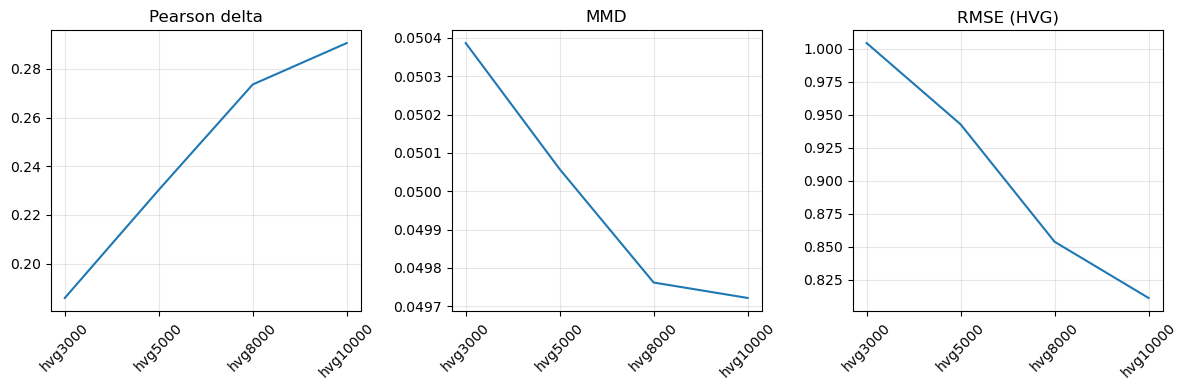

In [62]:
import matplotlib.pyplot as plt

names = [r["hvg_set"] for r in all_results]

pearson = [r["pearson_delta"] for r in all_results]

mmd = [r["mmd"] for r in all_results]

rmse = [r["rmse_hvg"] for r in all_results]


plt.figure(figsize=(12,4))


##################################
# Pearson delta
##################################

plt.subplot(1,3,1)

plt.plot(names, pearson)

plt.title("Pearson delta")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)


##################################
# MMD
##################################

plt.subplot(1,3,2)

plt.plot(names, mmd)

plt.title("MMD")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)


##################################
# RMSE
##################################

plt.subplot(1,3,3)

plt.plot(names, rmse)

plt.title("RMSE (HVG)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)


plt.tight_layout()

plt.show()

In [56]:
best_pearson = max(

    all_results,

    key=lambda x: x["pearson_delta"]

)

best_mmd = min(

    all_results,

    key=lambda x: x["mmd"]

)


print("\nBest HVG set:")

print(

    "Pearson delta best:",
    best_pearson["hvg_set"]

)

print(

    "MMD best:",
    best_mmd["hvg_set"]

)


Best HVG set:
Pearson delta best: hvg10000
MMD best: hvg8000
